In [1]:
# Imports & setup
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Plot settings
sns.set_theme(style='whitegrid', palette='Set2', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)

# Paths
DATA_DIR = Path(r'd:/MSAI/Semester 2/Deep Learning/Assignment/Assignment 1')
train_path = DATA_DIR / 'train.csv'
test_path = DATA_DIR / 'test.csv'

# Load data
df = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)  # loaded only to inspect columns; not used for model dev

print('Train shape:', df.shape)
print('Test shape:', df_test.shape)
display(df.head())

Train shape: (41348, 7)
Test shape: (7297, 7)


,neighbourhood_group,room_type,minimum_nights,amenity_score,number_of_reviews,availability_365,price_class
0,Manhattan,NaN,2.0,82.5,15.0,254.0,3
1,Manhattan,Private room,2.0,53.7,1.0,0.0,1
2,Brooklyn,Private room,2.0,47.8,70.0,90.0,1
3,Manhattan,Entire home/apt,2.0,58.8,1.0,NaN,1
4,Bronx,Private room,2.0,32.2,0.0,89.0,1


In [2]:
# 1) Dataset structure and data types
print('Rows:', len(df))
print('Columns:', df.shape[1])
print('\nColumns:', list(df.columns))
print('\nDtypes:')
display(df.dtypes)

print('\nBasic numeric summary:')
display(df.describe(include=[np.number]).T)

print('\nCategorical summary:')
categorical_cols = ['neighbourhood_group', 'room_type']
for col in categorical_cols:
    print(f"\n{col} - unique: {df[col].nunique(dropna=True)}")
    display(df[col].value_counts(dropna=False).head(10))

Rows: 41348
Columns: 7

Columns: ['neighbourhood_group', 'room_type', 'minimum_nights', 'amenity_score', 'number_of_reviews', 'availability_365', 'price_class']

Dtypes:


neighbourhood_group     object
room_type               object
minimum_nights         float64
amenity_score          float64
number_of_reviews      float64
availability_365       float64
price_class              int64
dtype: object


Basic numeric summary:


,count,mean,std,min,25%,50%,75%,max
minimum_nights,40026.0,7.002873,19.725353,1.0,1.0,3.0,5.0,1000.0
amenity_score,40432.0,51.987233,19.459480,10.0,36.8,51.4,66.1,99.0
number_of_reviews,40225.0,23.648154,44.518303,0.0,1.0,5.0,24.0,607.0
availability_365,40753.0,111.912178,131.273916,0.0,0.0,44.0,224.0,365.0
price_class,41348.0,1.231619,0.758579,0.0,1.0,1.0,2.0,3.0



Categorical summary:

neighbourhood_group - unique: 5


neighbourhood_group
Manhattan        17905
Brooklyn         16692
Queens            4696
Bronx              907
NaN                839
Staten Island      309
Name: count, dtype: int64


room_type - unique: 3


room_type
Entire home/apt    21099
Private room       18663
Shared room          975
NaN                  611
Name: count, dtype: int64

In [3]:
# 2) Missing values analysis
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_count / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
display(missing_df)

# Separate feature groups
target_col = 'price_class'
num_cols = ['minimum_nights', 'amenity_score', 'number_of_reviews', 'availability_365']
cat_cols = ['neighbourhood_group', 'room_type']

print('\nSkewness of numeric features (pre-imputation):')
display(df[num_cols].skew(numeric_only=True))

,missing_count,missing_pct
minimum_nights,1322,3.20
number_of_reviews,1123,2.72
amenity_score,916,2.22
neighbourhood_group,839,2.03
room_type,611,1.48
availability_365,595,1.44
price_class,0,0.00



Skewness of numeric features (pre-imputation):


minimum_nights       20.906450
amenity_score         0.082968
number_of_reviews     3.611505
availability_365      0.775323
dtype: float64

,count,pct
price_class,,
0,5567,13.46
1,23287,56.32
2,9844,23.81
3,2650,6.41


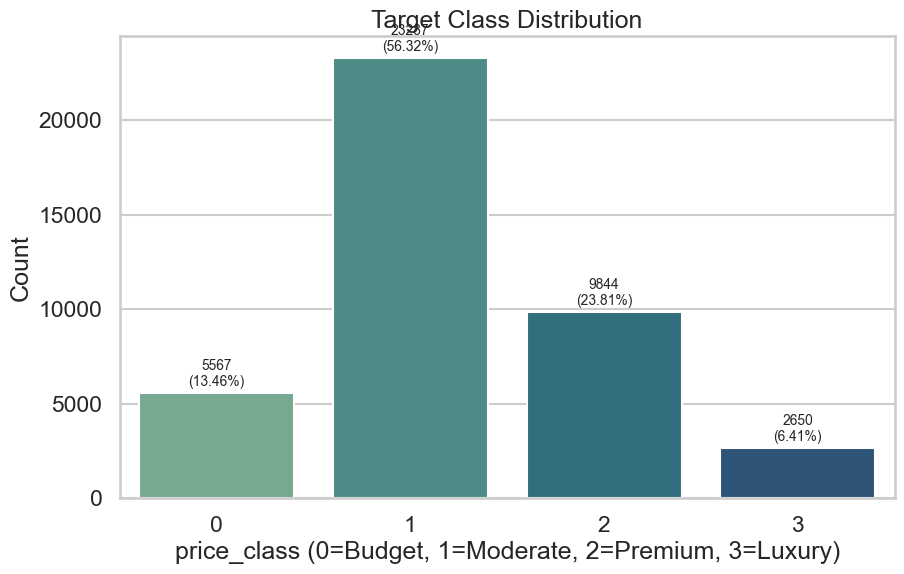

Imbalance ratio (max/min): 8.79


In [4]:
# 3) Target class distribution
target_counts = df[target_col].value_counts().sort_index()
target_pct = (target_counts / target_counts.sum() * 100).round(2)
display(pd.DataFrame({'count': target_counts, 'pct': target_pct}))

ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette='crest')
ax.set_xlabel('price_class (0=Budget, 1=Moderate, 2=Premium, 3=Luxury)')
ax.set_ylabel('Count')
ax.set_title('Target Class Distribution')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + max(target_counts.values)*0.01, f"{v}\n({target_pct.iloc[i]}%)", ha='center', va='bottom', fontsize=10)
plt.show()

print('Imbalance ratio (max/min):', round(target_counts.max()/target_counts.min(), 2))

In [5]:
# 4) Build processed dataset for modeling
df_proc = df.copy()

# Impute numeric with median
num_imputer = SimpleImputer(strategy='median')
df_proc[num_cols] = num_imputer.fit_transform(df_proc[num_cols])

# Impute categorical with most frequent
cat_imputer = SimpleImputer(strategy='most_frequent')
df_proc[cat_cols] = cat_imputer.fit_transform(df_proc[cat_cols])

# Log1p transform skewed numeric features
skewed_cols = ['minimum_nights', 'number_of_reviews']
for c in skewed_cols:
    df_proc[c + '_log1p'] = np.log1p(df_proc[c])

# Final numeric columns to scale
num_final = ['amenity_score', 'availability_365', 'minimum_nights_log1p', 'number_of_reviews_log1p']

# One-hot encode categoricals
df_ohe = pd.get_dummies(df_proc[cat_cols], drop_first=False, dtype=int)
ohe_cols = list(df_ohe.columns)

# Scale numeric
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(df_proc[num_final])
df_num_scaled = pd.DataFrame(X_num_scaled, columns=[c + '_z' for c in num_final], index=df_proc.index)

# Assemble final processed DataFrame (features only)
X_processed = pd.concat([df_num_scaled, df_ohe], axis=1)
y = df_proc[target_col].astype(int)

print('Processed feature shape:', X_processed.shape)
display(X_processed.head())

Processed feature shape: (41348, 12)


,amenity_score_z,availability_365_z,minimum_nights_log1p_z,number_of_reviews_log1p_z,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,1.586358,1.095654,-0.467229,0.490777,0,0,1,0,0,1,0,0
1,0.089685,-0.849587,-0.467229,-0.860817,0,0,1,0,0,0,1,0
2,-0.216925,-0.160329,-0.467229,1.459305,0,1,0,0,0,0,1,0
3,0.354721,-0.512616,-0.467229,-0.860817,0,0,1,0,0,1,0,0
4,-1.027623,-0.167987,-0.467229,-1.311348,1,0,0,0,0,0,1,0


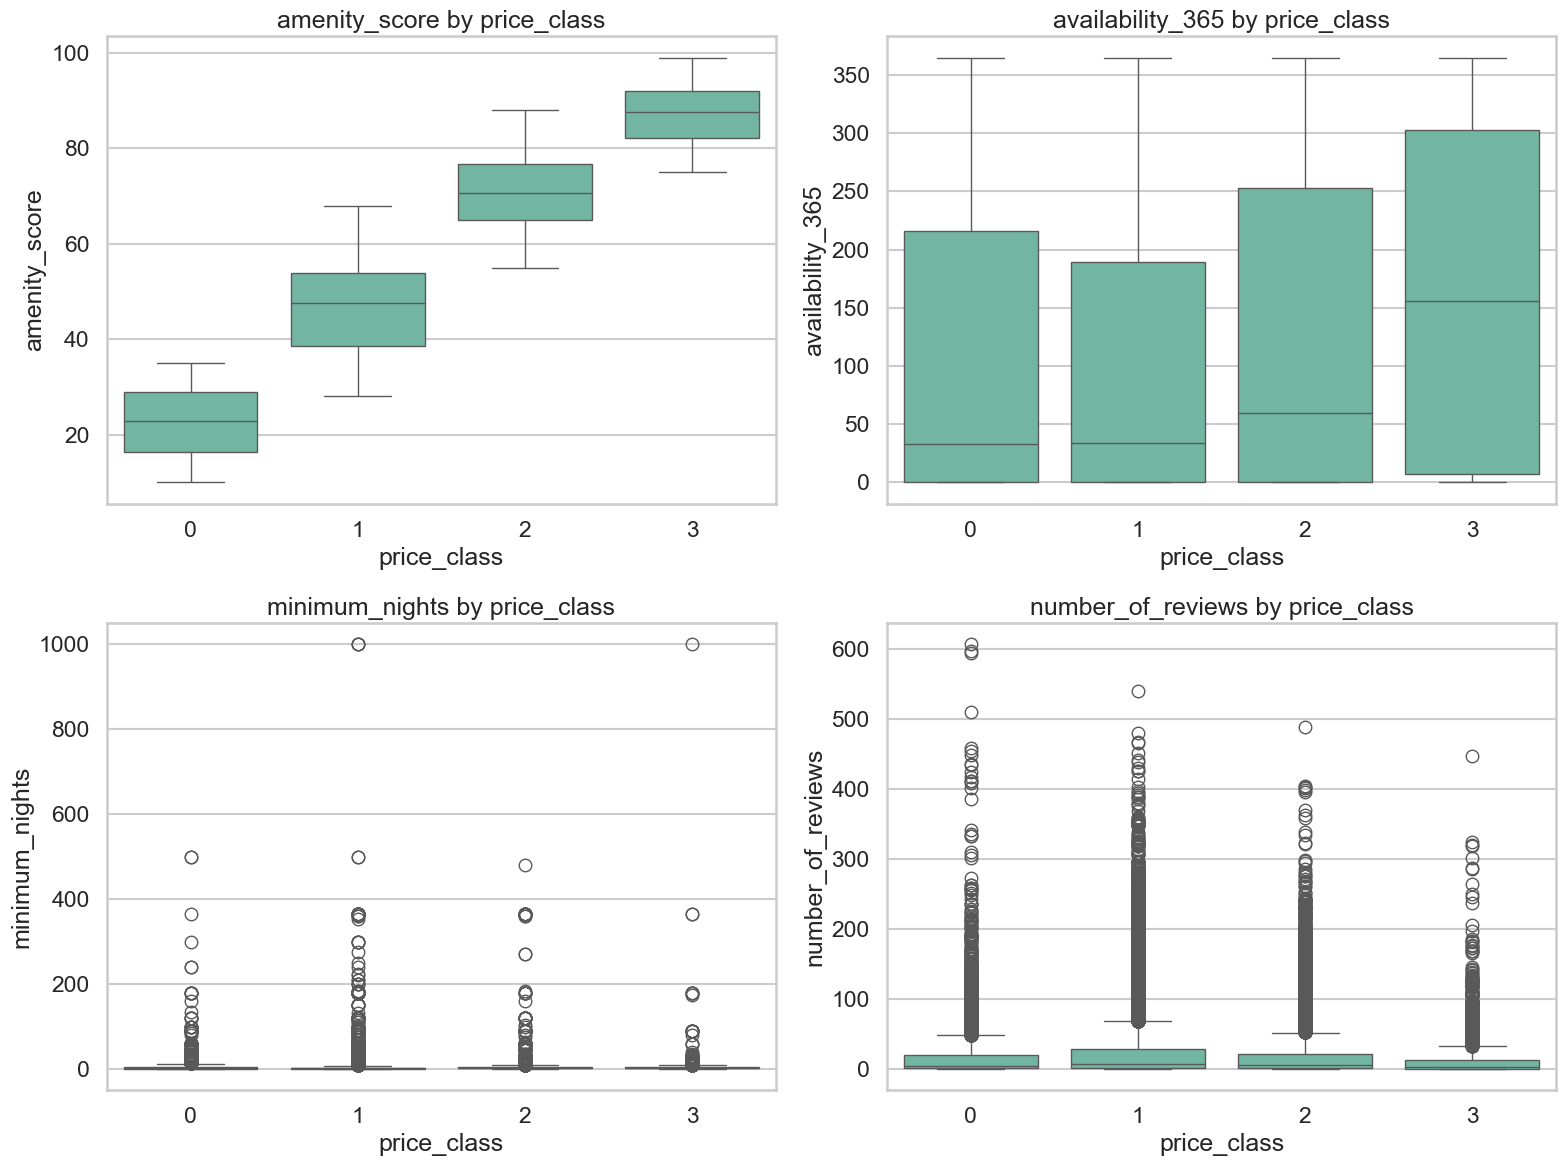

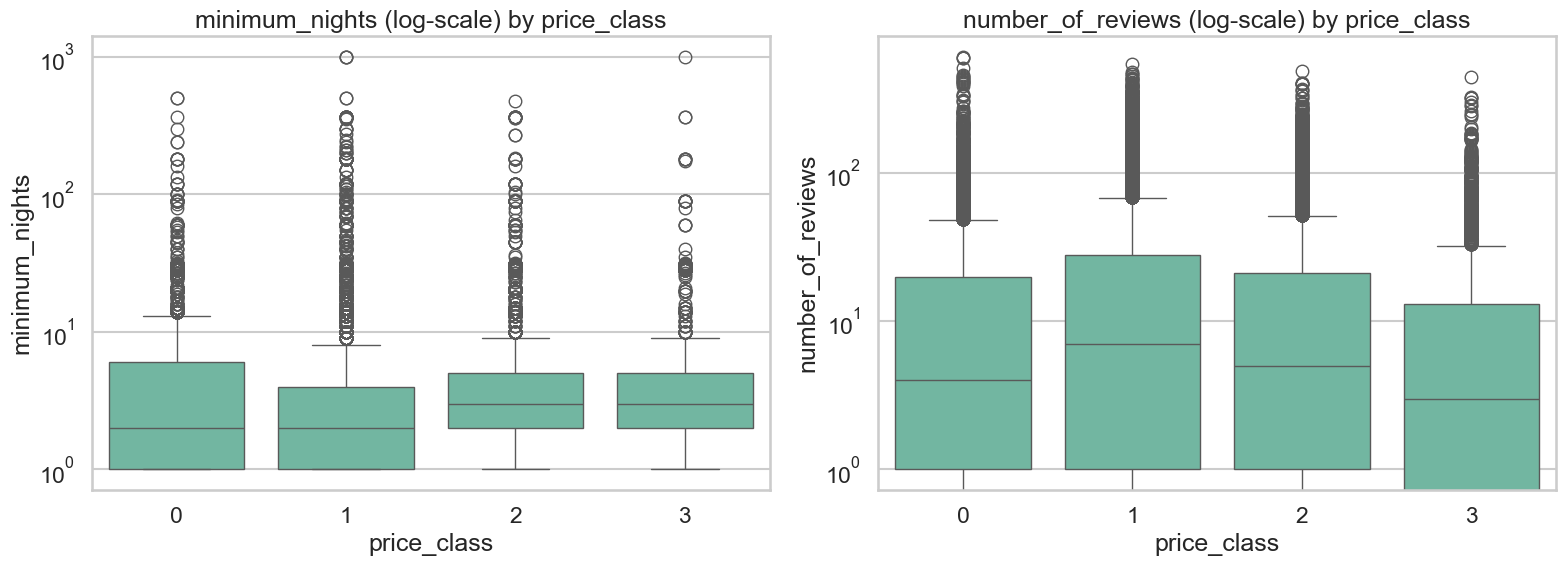

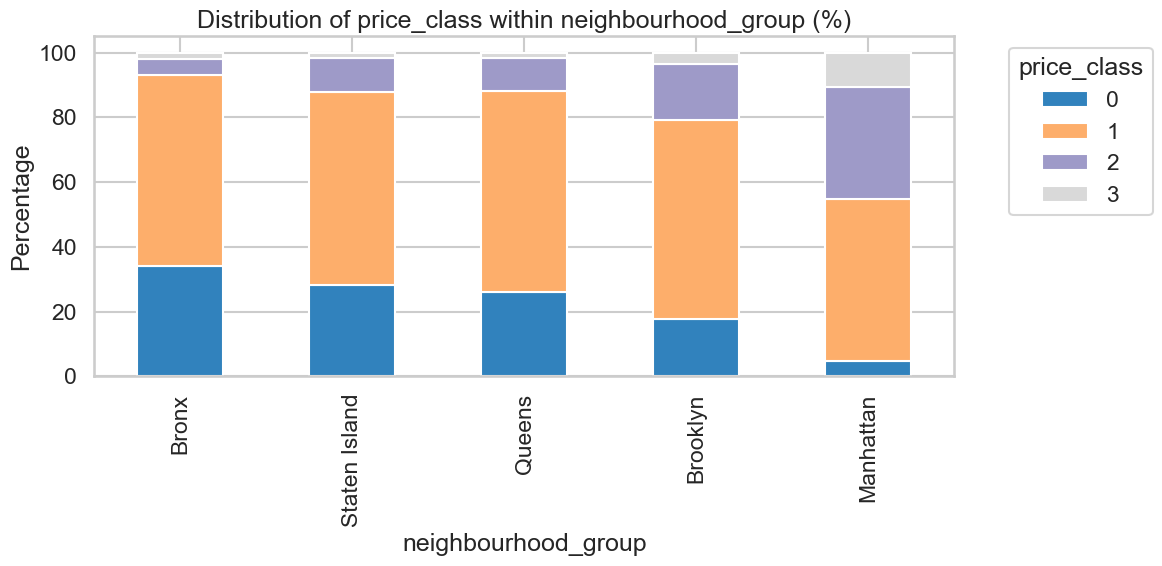

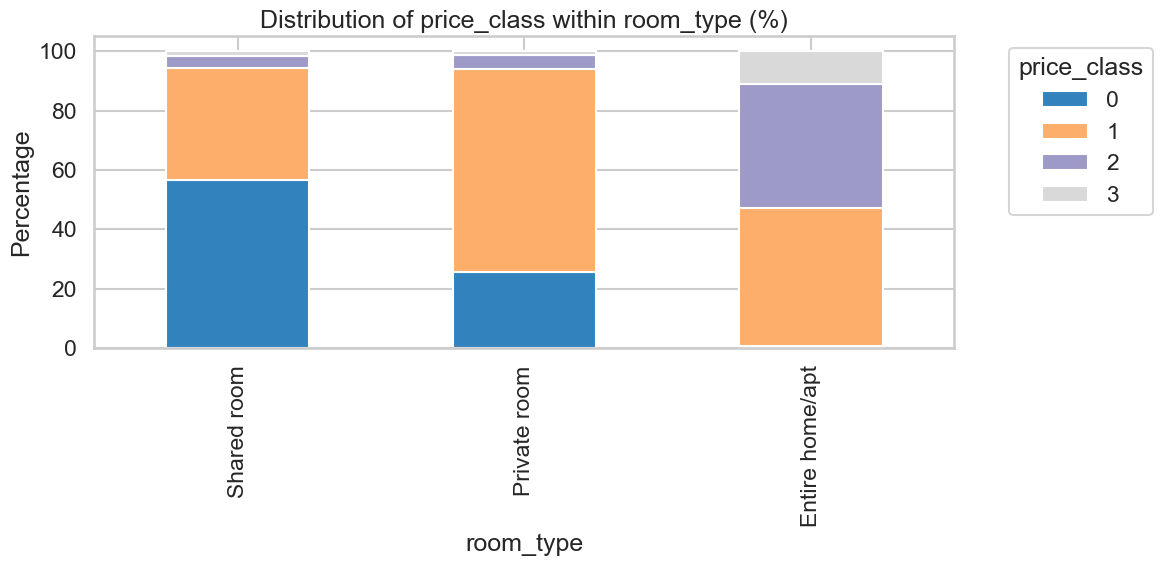

In [6]:
# 5) Feature–target relationships: numeric features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
num_plot_cols = ['amenity_score', 'availability_365', 'minimum_nights', 'number_of_reviews']
for ax, col in zip(axes.flat, num_plot_cols):
    sns.boxplot(data=df, x=target_col, y=col, ax=ax)
    ax.set_title(f'{col} by price_class')
plt.tight_layout()
plt.show()

# Use log scale for skewed features for clarity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col in zip(axes.flat, ['minimum_nights', 'number_of_reviews']):
    sns.boxplot(data=df, x=target_col, y=col, ax=ax)
    ax.set_yscale('log')
    ax.set_title(f'{col} (log-scale) by price_class')
plt.tight_layout()
plt.show()

# 6) Feature–target relationships: categorical features
def stacked_bar(col):
    ct = pd.crosstab(df[col], df[target_col], normalize='index') * 100
    ct = ct.sort_values(by=list(ct.columns), ascending=False)
    ct.plot(kind='bar', stacked=True, colormap='tab20c', figsize=(12,6))
    plt.title(f'Distribution of price_class within {col} (%)')
    plt.ylabel('Percentage')
    plt.legend(title='price_class', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

stacked_bar('neighbourhood_group')
stacked_bar('room_type')

,minimum_nights,amenity_score,number_of_reviews,availability_365
minimum_nights,1.000000,0.023137,-0.081572,0.134664
amenity_score,0.023137,1.000000,-0.030034,0.079270
number_of_reviews,-0.081572,-0.030034,1.000000,0.170843
availability_365,0.134664,0.079270,0.170843,1.000000


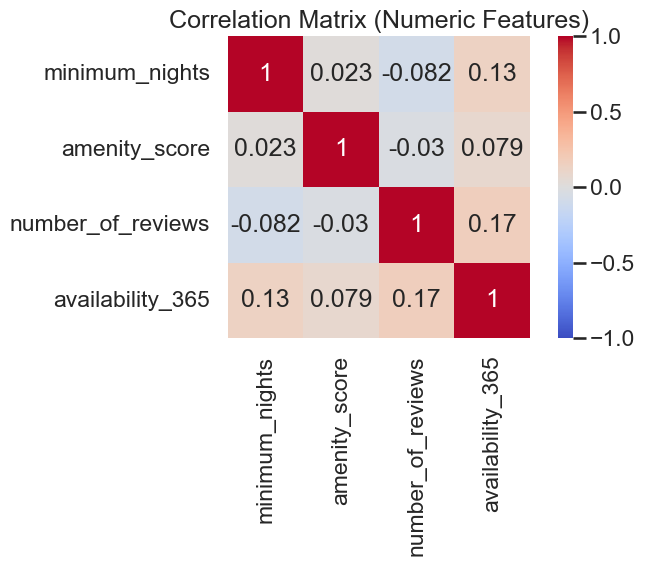

No pairs exceed the threshold.


In [7]:
# 7) Correlation matrix among numeric features
corr = df_proc[num_cols].corr()
display(corr)
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix (Numeric Features)')
plt.tight_layout()
plt.show()

# Identify highly correlated pairs
threshold = 0.7
pairs = []
for i, c1 in enumerate(num_cols):
    for j, c2 in enumerate(num_cols):
        if j <= i:
            continue
        r = corr.loc[c1, c2]
        if abs(r) >= threshold:
            pairs.append((c1, c2, r))
if pairs:
    print('Highly correlated (|r| >=', threshold, '):')
    for p in pairs:
        print(f'{p[0]} vs {p[1]}: r={p[2]:.2f}')
else:
    print('No pairs exceed the threshold.')

In [8]:
# Part B(a) — Data prep (split + one-hot)
import numpy as np
from sklearn.model_selection import train_test_split

np.random.seed(42)

X = X_processed.values.astype(np.float32)
y_array = y.values.astype(int)
n_classes = int(y_array.max() + 1)

# Stratified train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y_array, test_size=0.2, random_state=42, stratify=y_array)

def one_hot(y, num_classes):
    Y = np.zeros((y.shape[0], num_classes), dtype=np.float32)
    Y[np.arange(y.shape[0]), y] = 1.0
    return Y

Y_train = one_hot(y_train, n_classes)
Y_val = one_hot(y_val, n_classes)

X_train.shape, X_val.shape, Y_train.shape, Y_val.shape

((33078, 12), (8270, 12), (33078, 4), (8270, 4))

In [9]:
# Part B(a) — Two-hidden-layer MLP (NumPy only)
import numpy as np

class TwoLayerMLP:
    def __init__(self, input_dim, h1, h2, output_dim, activation='relu', seed=42):
        assert activation in ('relu', 'sigmoid')
        self.act_name = activation
        rng = np.random.default_rng(seed)
        if activation == 'relu':
            self.W1 = rng.normal(0, np.sqrt(2.0/input_dim), size=(input_dim, h1)).astype(np.float32)
            self.W2 = rng.normal(0, np.sqrt(2.0/h1), size=(h1, h2)).astype(np.float32)
        else:  # sigmoid → Xavier
            self.W1 = rng.normal(0, np.sqrt(1.0/input_dim), size=(input_dim, h1)).astype(np.float32)
            self.W2 = rng.normal(0, np.sqrt(1.0/h1), size=(h1, h2)).astype(np.float32)
        self.W3 = rng.normal(0, np.sqrt(1.0/h2), size=(h2, output_dim)).astype(np.float32)
        self.b1 = np.zeros((1, h1), dtype=np.float32)
        self.b2 = np.zeros((1, h2), dtype=np.float32)
        self.b3 = np.zeros((1, output_dim), dtype=np.float32)

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-z))

    @staticmethod
    def _relu(z):
        return np.maximum(0, z)

    @staticmethod
    def _softmax(z):
        z = z - z.max(axis=1, keepdims=True)
        expz = np.exp(z)
        return expz / expz.sum(axis=1, keepdims=True)

    def _act(self, z):
        return self._relu(z) if self.act_name == 'relu' else self._sigmoid(z)

    def _act_grad(self, a, z):
        if self.act_name == 'relu':
            return (z > 0).astype(np.float32)
        else:
            return a * (1.0 - a)

    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        a1 = self._act(z1)
        z2 = a1 @ self.W2 + self.b2
        a2 = self._act(z2)
        z3 = a2 @ self.W3 + self.b3
        probs = self._softmax(z3)
        cache = {'X': X, 'z1': z1, 'a1': a1, 'z2': z2, 'a2': a2, 'z3': z3, 'probs': probs}
        return probs, cache

    def loss(self, probs, Y):
        eps = 1e-12
        N = Y.shape[0]
        log_likelihood = -np.log(probs[np.arange(N), Y.argmax(1)] + eps)
        return log_likelihood.mean()

    def backward(self, cache, Y):
        X, z1, a1, z2, a2, z3, probs = (cache['X'], cache['z1'], cache['a1'], cache['z2'], cache['a2'], cache['z3'], cache['probs'])
        N = X.shape[0]

        dz3 = (probs - Y) / N
        dW3 = a2.T @ dz3
        db3 = dz3.sum(axis=0, keepdims=True)

        da2 = dz3 @ self.W3.T
        dz2 = da2 * self._act_grad(a2, z2)
        dW2 = a1.T @ dz2
        db2 = dz2.sum(axis=0, keepdims=True)

        da1 = dz2 @ self.W2.T
        dz1 = da1 * self._act_grad(a1, z1)
        dW1 = X.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)

        grads = {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2, 'dW3': dW3, 'db3': db3}
        return grads

    def update(self, grads, lr):
        self.W1 -= lr * grads['dW1']
        self.b1 -= lr * grads['db1']
        self.W2 -= lr * grads['dW2']
        self.b2 -= lr * grads['db2']
        self.W3 -= lr * grads['dW3']
        self.b3 -= lr * grads['db3']

def accuracy(model, X, y_true):
    probs, _ = model.forward(X)
    y_pred = probs.argmax(1)
    return (y_pred == y_true).mean()

def train_model(X_train, Y_train, X_val, Y_val, y_train, y_val, activation, epochs=250, lr=0.1, h1=64, h2=32, seed=42):
    model = TwoLayerMLP(X_train.shape[1], h1, h2, Y_train.shape[1], activation=activation, seed=seed)
    train_acc_hist, val_acc_hist, loss_hist = [], [], []
    for t in range(epochs):
        probs, cache = model.forward(X_train)
        L = model.loss(probs, Y_train)
        grads = model.backward(cache, Y_train)
        model.update(grads, lr)
        # metrics
        train_acc = accuracy(model, X_train, y_train)
        val_acc = accuracy(model, X_val, y_val)
        train_acc_hist.append(train_acc)
        val_acc_hist.append(val_acc)
        loss_hist.append(L)
        if (t+1) % 50 == 0:
            print(f'Epoch {t+1:3d}  Loss={L:.4f}  TrainAcc={train_acc:.3f}  ValAcc={val_acc:.3f}')
    return model, {'train_acc': np.array(train_acc_hist), 'val_acc': np.array(val_acc_hist), 'loss': np.array(loss_hist)}

# Train Sigmoid and ReLU models
sig_model, sig_hist = train_model(X_train, Y_train, X_val, Y_val, y_train, y_val, activation='sigmoid', epochs=250, lr=0.1, h1=64, h2=32, seed=42)
relu_model, relu_hist = train_model(X_train, Y_train, X_val, Y_val, y_train, y_val, activation='relu', epochs=250, lr=0.1, h1=64, h2=32, seed=42)

sig_train_acc = sig_hist['train_acc'][-1]
sig_val_acc = sig_hist['val_acc'][-1]
relu_train_acc = relu_hist['train_acc'][-1]
relu_val_acc = relu_hist['val_acc'][-1]

print('\nFinal Accuracies:')
print(f'Sigmoid -> Train: {sig_train_acc:.3f}, Val: {sig_val_acc:.3f}')
print(f'ReLU    -> Train: {relu_train_acc:.3f}, Val: {relu_val_acc:.3f}')

Epoch  50  Loss=1.0829  TrainAcc=0.563  ValAcc=0.563
Epoch 100  Loss=1.0560  TrainAcc=0.563  ValAcc=0.563
Epoch 150  Loss=1.0178  TrainAcc=0.563  ValAcc=0.563
Epoch 200  Loss=0.9651  TrainAcc=0.567  ValAcc=0.569
Epoch 250  Loss=0.9009  TrainAcc=0.632  ValAcc=0.630
Epoch  50  Loss=0.5957  TrainAcc=0.770  ValAcc=0.764
Epoch 100  Loss=0.4615  TrainAcc=0.807  ValAcc=0.803
Epoch 150  Loss=0.4146  TrainAcc=0.822  ValAcc=0.815
Epoch 200  Loss=0.3945  TrainAcc=0.829  ValAcc=0.820
Epoch 250  Loss=0.3847  TrainAcc=0.831  ValAcc=0.825

Final Accuracies:
Sigmoid -> Train: 0.632, Val: 0.630
ReLU    -> Train: 0.831, Val: 0.825


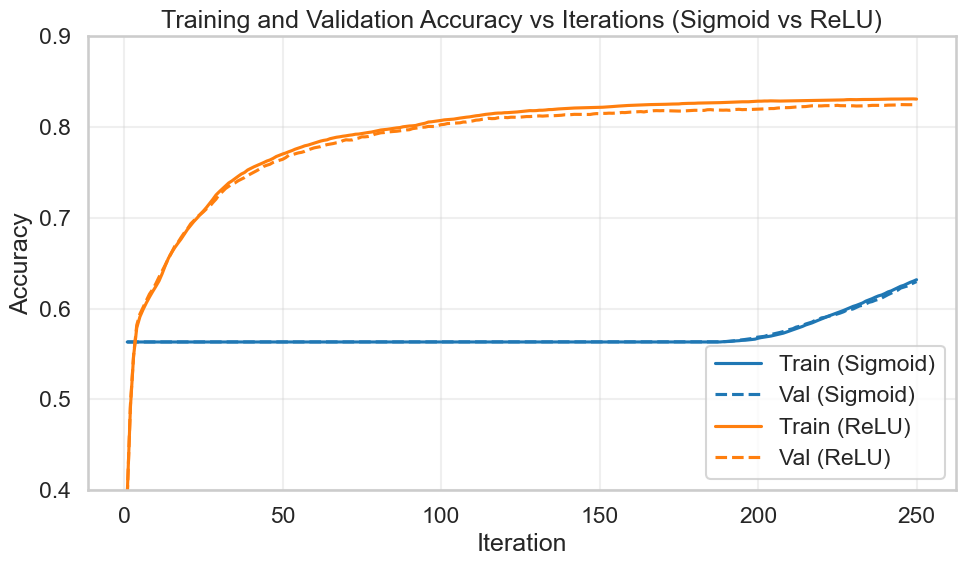

In [10]:
# Part B(a) — Combined accuracy plot
epochs = np.arange(1, len(sig_hist['train_acc'])+1)
plt.figure(figsize=(10,6))
plt.plot(epochs, sig_hist['train_acc'], label='Train (Sigmoid)', color='#1f77b4')
plt.plot(epochs, sig_hist['val_acc'], label='Val (Sigmoid)', color='#1f77b4', linestyle='--')
plt.plot(epochs, relu_hist['train_acc'], label='Train (ReLU)', color='#ff7f0e')
plt.plot(epochs, relu_hist['val_acc'], label='Val (ReLU)', color='#ff7f0e', linestyle='--')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy vs Iterations (Sigmoid vs ReLU)')
plt.legend()
plt.ylim(0.4, 0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Part B(b): Gradient Magnitude Comparison Across Layers
We track mean absolute gradients for the first and second hidden layers across iterations to study gradient flow for Sigmoid vs ReLU.

In [11]:

def train_with_grad_hist(X_train, Y_train, X_val, Y_val, y_train, y_val, activation, epochs=250, lr=0.1, h1=64, h2=32, seed=123):
    model = TwoLayerMLP(X_train.shape[1], h1, h2, Y_train.shape[1], activation=activation, seed=seed)
    train_acc_hist, val_acc_hist, loss_hist = [], [], []
    gW1_hist, gW2_hist = [], []
    for t in range(epochs):
        probs, cache = model.forward(X_train)
        L = model.loss(probs, Y_train)
        grads = model.backward(cache, Y_train)
        # record gradient magnitudes (mean absolute)
        gW1_hist.append(np.mean(np.abs(grads['dW1'])))
        gW2_hist.append(np.mean(np.abs(grads['dW2'])))
        model.update(grads, lr)
        # metrics
        train_acc_hist.append(accuracy(model, X_train, y_train))
        val_acc_hist.append(accuracy(model, X_val, y_val))
        loss_hist.append(L)
        if (t+1) % 50 == 0:
            print(f'[{activation}] Epoch {t+1:3d}  Loss={L:.4f}  TrainAcc={train_acc_hist[-1]:.3f}  ValAcc={val_acc_hist[-1]:.3f}')
    return model, {
        'train_acc': np.array(train_acc_hist),
        'val_acc': np.array(val_acc_hist),
        'loss': np.array(loss_hist),
        'gW1': np.array(gW1_hist),
        'gW2': np.array(gW2_hist),
    }

sig_model_g, sig_hist_g = train_with_grad_hist(X_train, Y_train, X_val, Y_val, y_train, y_val, activation='sigmoid', epochs=250, lr=0.1, h1=64, h2=32, seed=123)
relu_model_g, relu_hist_g = train_with_grad_hist(X_train, Y_train, X_val, Y_val, y_train, y_val, activation='relu', epochs=250, lr=0.1, h1=64, h2=32, seed=123)

print('\nFinal (with grad tracking) Accuracies:')
print(f"Sigmoid -> Train: {sig_hist_g['train_acc'][-1]:.3f}, Val: {sig_hist_g['val_acc'][-1]:.3f}")
print(f"ReLU    -> Train: {relu_hist_g['train_acc'][-1]:.3f}, Val: {relu_hist_g['val_acc'][-1]:.3f}")

[sigmoid] Epoch  50  Loss=1.0890  TrainAcc=0.563  ValAcc=0.563
[sigmoid] Epoch 100  Loss=1.0649  TrainAcc=0.563  ValAcc=0.563
[sigmoid] Epoch 150  Loss=1.0287  TrainAcc=0.563  ValAcc=0.563
[sigmoid] Epoch 200  Loss=0.9764  TrainAcc=0.563  ValAcc=0.563
[sigmoid] Epoch 250  Loss=0.9100  TrainAcc=0.614  ValAcc=0.613
[relu] Epoch  50  Loss=0.5477  TrainAcc=0.785  ValAcc=0.778
[relu] Epoch 100  Loss=0.4403  TrainAcc=0.814  ValAcc=0.808
[relu] Epoch 150  Loss=0.4046  TrainAcc=0.827  ValAcc=0.819
[relu] Epoch 200  Loss=0.3895  TrainAcc=0.831  ValAcc=0.824
[relu] Epoch 250  Loss=0.3819  TrainAcc=0.833  ValAcc=0.823

Final (with grad tracking) Accuracies:
Sigmoid -> Train: 0.614, Val: 0.613
ReLU    -> Train: 0.833, Val: 0.823


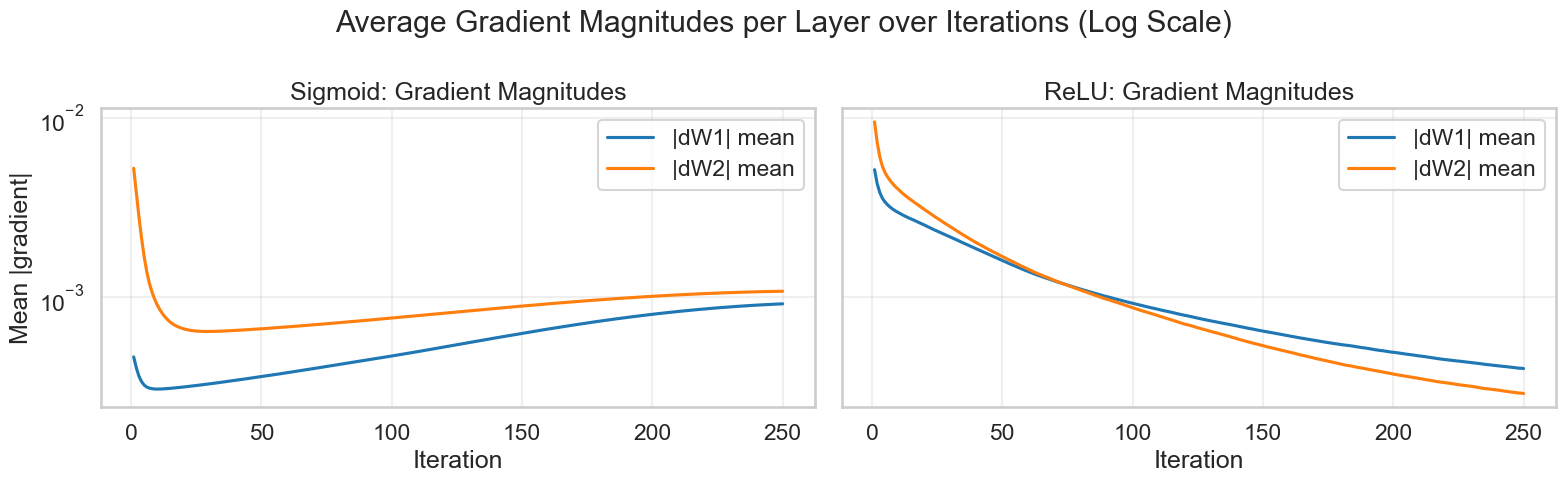

Final mean |grad| (Sigmoid)  dW1: 0.0009216939215548337  dW2: 0.0010827613295987248
Final mean |grad| (ReLU)     dW1: 0.00040221321978606284  dW2: 0.0002920416882261634


In [12]:
# Plot gradient magnitudes across iterations
iters = np.arange(1, len(sig_hist_g['gW1'])+1)
fig, axes = plt.subplots(1, 2, figsize=(16,5), sharey=True)

# Sigmoid
axes[0].plot(iters, sig_hist_g['gW1'], label='|dW1| mean', color='#1f77b4')
axes[0].plot(iters, sig_hist_g['gW2'], label='|dW2| mean', color='#ff7f0e')
axes[0].set_title('Sigmoid: Gradient Magnitudes')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Mean |gradient|')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ReLU
axes[1].plot(iters, relu_hist_g['gW1'], label='|dW1| mean', color='#1f77b4')
axes[1].plot(iters, relu_hist_g['gW2'], label='|dW2| mean', color='#ff7f0e')
axes[1].set_title('ReLU: Gradient Magnitudes')
axes[1].set_xlabel('Iteration')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Average Gradient Magnitudes per Layer over Iterations (Log Scale)')
plt.tight_layout()
plt.show()

print('Final mean |grad| (Sigmoid)  dW1:', float(sig_hist_g['gW1'][-1]), ' dW2:', float(sig_hist_g['gW2'][-1]))
print('Final mean |grad| (ReLU)     dW1:', float(relu_hist_g['gW1'][-1]), ' dW2:', float(relu_hist_g['gW2'][-1]))

In [13]:
# C(b) — Compute input gradients and rank features
import pandas as pd

def act_grad_from(model, a, z):
    if model.act_name == 'relu':
        return (z > 0).astype(np.float32)
    else:
        return a * (1.0 - a)

def input_gradients(model, X, Y):
    # Per-sample gradients of cross-entropy loss wrt inputs (no 1/N scaling)
    probs, cache = model.forward(X)
    z1, a1, z2, a2 = cache['z1'], cache['a1'], cache['z2'], cache['a2']
    delta3 = (probs - Y)  # shape (N, K)
    delta2 = (delta3 @ model.W3.T) * act_grad_from(model, a2, z2)  # (N, h2)
    delta1 = (delta2 @ model.W2.T) * act_grad_from(model, a1, z1)  # (N, h1)
    gX = delta1 @ model.W1.T  # (N, d)
    return gX

def rank_features(model, X, Y, feature_names, topk=12):
    gX = input_gradients(model, X, Y)
    imp = np.mean(np.abs(gX), axis=0)
    s = pd.Series(imp, index=feature_names).sort_values(ascending=False)
    return s, gX

feature_names = list(X_processed.columns)

sig_rank, sig_gX = rank_features(sig_model_g, X_val, Y_val, feature_names, topk=12)
relu_rank, relu_gX = rank_features(relu_model_g, X_val, Y_val, feature_names, topk=12)

display(pd.DataFrame({'Sigmoid_importance': sig_rank, 'ReLU_importance': relu_rank}))

,Sigmoid_importance,ReLU_importance
amenity_score_z,0.159027,1.040821
availability_365_z,0.016503,0.103097
minimum_nights_log1p_z,0.006562,0.079621
neighbourhood_group_Bronx,0.006325,0.158176
neighbourhood_group_Brooklyn,0.059247,0.241571
neighbourhood_group_Manhattan,0.017481,0.237367
neighbourhood_group_Queens,0.035958,0.219899
neighbourhood_group_Staten Island,0.022646,0.137511
number_of_reviews_log1p_z,0.035732,0.099442
room_type_Entire home/apt,0.064466,0.328096


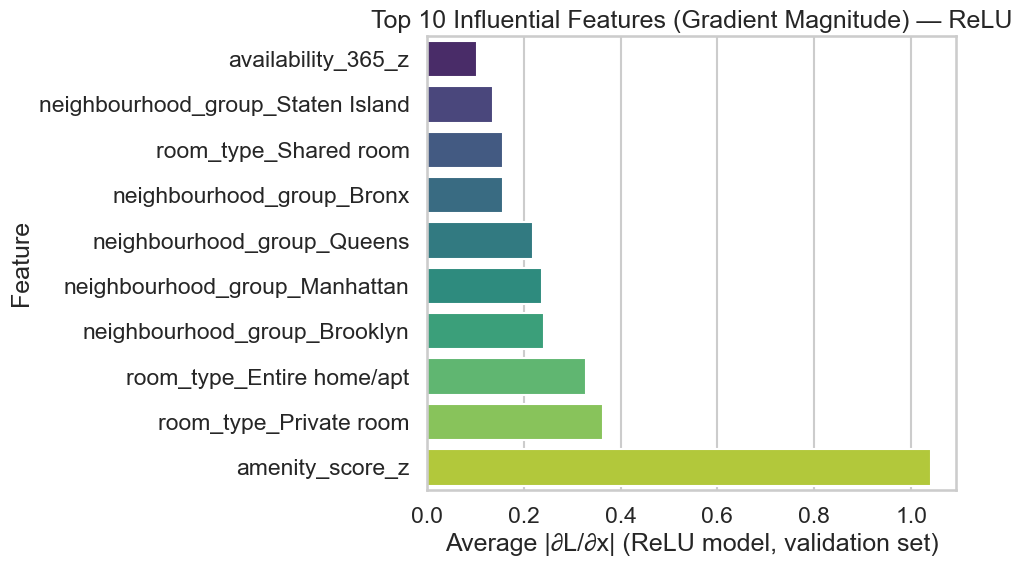

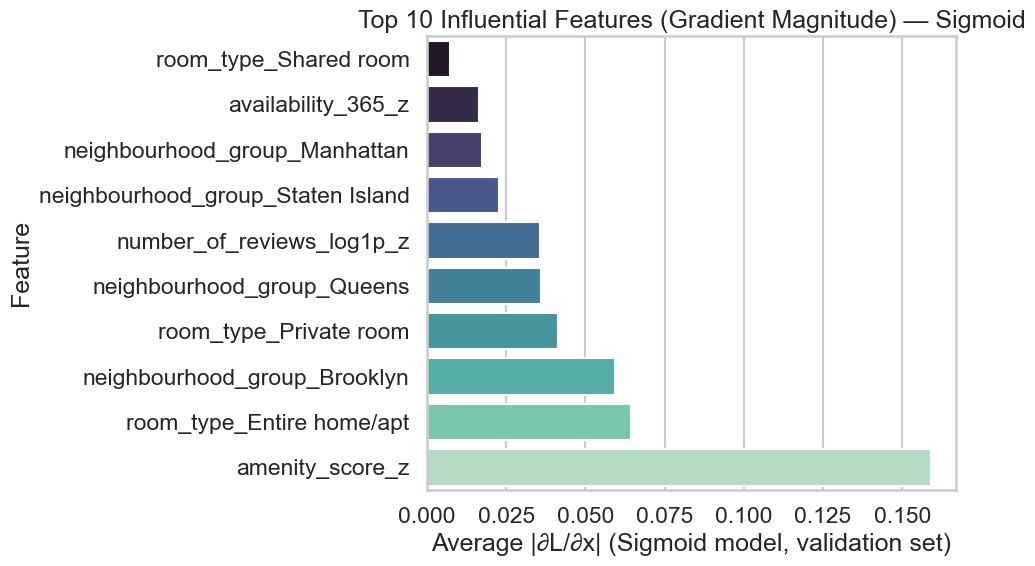

In [14]:
# Plot top features (ReLU)
topk = 10
relu_top = relu_rank.head(topk)[::-1]
plt.figure(figsize=(10,6))
sns.barplot(x=relu_top.values, y=relu_top.index, palette='viridis')
plt.xlabel('Average |∂L/∂x| (ReLU model, validation set)')
plt.ylabel('Feature')
plt.title(f'Top {topk} Influential Features (Gradient Magnitude) — ReLU')
plt.tight_layout()
plt.show()

# Plot top features (Sigmoid)
sig_top = sig_rank.head(topk)[::-1]
plt.figure(figsize=(10,6))
sns.barplot(x=sig_top.values, y=sig_top.index, palette='mako')
plt.xlabel('Average |∂L/∂x| (Sigmoid model, validation set)')
plt.ylabel('Feature')
plt.title(f'Top {topk} Influential Features (Gradient Magnitude) — Sigmoid')
plt.tight_layout()
plt.show()

In [15]:
# D — Preprocess test set and evaluate
def preprocess_test(df_test_raw):
    df_t = df_test_raw.copy()
    # Impute (use training-fitted imputers)
    df_t[num_cols] = num_imputer.transform(df_t[num_cols])
    df_t[cat_cols] = cat_imputer.transform(df_t[cat_cols])
    # Log1p
    for c in skewed_cols:
        df_t[c + '_log1p'] = np.log1p(df_t[c])
    # Numeric scaling (training scaler)
    Xn = scaler.transform(df_t[num_final])
    df_num_scaled_t = pd.DataFrame(Xn, columns=[c + '_z' for c in num_final], index=df_t.index)
    # One-hot categoricals and align columns
    df_ohe_t = pd.get_dummies(df_t[cat_cols], drop_first=False, dtype=int)
    # Ensure same dummy columns order as training
    df_ohe_t = df_ohe_t.reindex(columns=ohe_cols, fill_value=0)
    X_t = pd.concat([df_num_scaled_t, df_ohe_t], axis=1)
    # Final column order exactly like training features
    X_t = X_t.reindex(columns=feature_names)
    y_t = df_t[target_col].astype(int) if target_col in df_t.columns else None
    return X_t.values.astype(np.float32), y_t.values.astype(int) if y_t is not None else None

X_test, y_test = preprocess_test(df_test)
print('Test features shape:', X_test.shape, ' Target present:', y_test is not None)

def evaluate_all(sig_model, relu_model, X_tr, y_tr, X_va, y_va, X_te, y_te):
    rows = []
    for name, m in [('Sigmoid', sig_model), ('ReLU', relu_model)]:
        tr = accuracy(m, X_tr, y_tr)
        va = accuracy(m, X_va, y_va)
        te = accuracy(m, X_te, y_te) if y_te is not None else np.nan
        rows.append({'Model': name, 'Train': tr, 'Val': va, 'Test': te})
    return pd.DataFrame(rows).set_index('Model')

results = evaluate_all(sig_model_g, relu_model_g, X_train, y_train, X_val, y_val, X_test, y_test)
display(results)

Test features shape: (7297, 12)  Target present: True


,Train,Val,Test
Model,,,
Sigmoid,0.613520,0.612817,0.550363
ReLU,0.832729,0.823458,0.366315


In [16]:
# Compare distributions: train vs test
def simple_dist_report(train_df, test_df):
    print('Class distribution: train vs test')
    tr = df[target_col].value_counts(normalize=True).sort_index().rename('train_pct')
    te = test_df[target_col].value_counts(normalize=True).sort_index().rename('test_pct')
    display(pd.concat([tr, te], axis=1).fillna(0).round(3))
    print('\nRoom type share (train vs test)')
    tr = df['room_type'].value_counts(normalize=True).rename('train_pct')
    te = test_df['room_type'].value_counts(normalize=True).rename('test_pct')
    display(pd.concat([tr, te], axis=1).fillna(0).round(3))
    print('\nBorough share (train vs test)')
    tr = df['neighbourhood_group'].value_counts(normalize=True).rename('train_pct')
    te = test_df['neighbourhood_group'].value_counts(normalize=True).rename('test_pct')
    display(pd.concat([tr, te], axis=1).fillna(0).round(3))
    print('\nNumeric means (train vs test)')
    num = ['amenity_score','availability_365','minimum_nights','number_of_reviews']
    trm = df[num].mean().rename('train_mean')
    tem = test_df[num].mean().rename('test_mean')
    display(pd.concat([trm, tem], axis=1).round(2))

simple_dist_report(df, df_test)

Class distribution: train vs test


,train_pct,test_pct
price_class,,
0,0.135,0.135
1,0.563,0.563
2,0.238,0.238
3,0.064,0.064



Room type share (train vs test)


,train_pct,test_pct
room_type,,
Entire home/apt,0.518,0.523
Private room,0.458,0.453
Shared room,0.024,0.023



Borough share (train vs test)


,train_pct,test_pct
neighbourhood_group,,
Manhattan,0.442,0.442
Brooklyn,0.412,0.412
Queens,0.116,0.116
Bronx,0.022,0.022
Staten Island,0.008,0.008



Numeric means (train vs test)


,train_mean,test_mean
amenity_score,51.99,54.15
availability_365,111.91,113.01
minimum_nights,7.00,7.11
number_of_reviews,23.65,23.54


In [17]:
# Sanity check: evaluate earlier-trained models (without grad history) on test
if 'relu_model' in globals() and 'sig_model' in globals():
    results_v1 = evaluate_all(sig_model, relu_model, X_train, y_train, X_val, y_val, X_test, y_test)
    print('Earlier models (no grad tracking):')
    display(results_v1)

Earlier models (no grad tracking):


,Train,Val,Test
Model,,,
Sigmoid,0.631779,0.629746,0.556804
ReLU,0.830854,0.824667,0.375908


In [18]:
# Missingness comparison (train vs test)
miss_train = (df.isna().mean()*100).round(2).rename('train_missing_%')
miss_test = (df_test.isna().mean()*100).round(2).rename('test_missing_%')
display(pd.concat([miss_train, miss_test], axis=1))

,train_missing_%,test_missing_%
neighbourhood_group,2.03,0.0
room_type,1.48,0.0
minimum_nights,3.20,0.0
amenity_score,2.22,0.0
number_of_reviews,2.72,0.0
availability_365,1.44,0.0
price_class,0.00,0.0
